# Your retirement luck depends on when you were born

A worker starts saving at age 25, puts away the equivalent of \$1,000/year (in constant
purchasing power) into an S&P 500 index fund, and keeps it up for 40 years. How much
real wealth does she have at age 65? It depends almost entirely on **the calendar
year she happened to start**.

This notebook runs the experiment for every starting cohort from 1950 to 1985 (a
40-year career ending by 2024 at the latest), and a shorter 10-year version for every
starting cohort from 1950 to 2015. Each cohort contributes the same real \$1,000 per
year, so the only thing that varies is the sequence of returns and inflation they
lived through. Final net worth is reported in 2025-equivalent dollars.

**Data sources**
- S&P 500 annual total returns (price + reinvested dividends), 1928–2025:
  [Damodaran "Historical Returns on Stocks, Bonds and Bills"](https://pages.stern.nyu.edu/~adamodar/New_Home_Page/datafile/histretSP.html).
- Annual CPI inflation, FRED `CPIAUCNS` (republished in the same Damodaran workbook).

All simulation and plotting code lives in [`dca.py`](dca.py); the raw historical
series is in [`historical_returns.csv`](historical_returns.csv).


In [2]:
%load_ext autoreload
%autoreload 2

import dca

returns = dca.load_returns()
returns.head()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ModuleNotFoundError: No module named 'pandas'

## Method

Each cohort contributes \$1,000 in **real** (constant) dollars at the start of every
career year. Working in real terms is equivalent to inflating the contribution and
deflating the final value: the real return each year is

$$r_{real} = \frac{1 + r_{nominal}}{1 + \pi} - 1$$

and the final real net worth after $N$ years is

$$W_N = \sum_{k=0}^{N-1} 1000 \cdot \prod_{j=k}^{N-1} (1 + r_{real, Y+j})$$

where $Y$ is the cohort's first career year. The dashed line on each chart marks
the total amount contributed in real dollars (\$40,000 for a 40-year career,
\$10,000 for a 10-year career) — anything above it is real investment gain.


## 40-year careers: starting 1950 through 1985

In [ ]:
t40 = dca.cohort_table(returns, range(1950, 1986), n_years=40)
print(t40.to_string(index=False,
    formatters={
        'final_real_net_worth': '${:,.0f}'.format,
        'multiple_of_contributed': '{:.2f}x'.format,
        'real_cagr': '{:.2%}'.format,
    }))

 start_year  end_year final_real_net_worth multiple_of_contributed real_cagr
       1950      1989             $189,159                   4.73x     7.85%
       1951      1990             $154,975                   3.87x     7.04%
       1952      1991             $177,909                   4.45x     7.25%
       1953      1992             $169,718                   4.24x     6.94%
       1954      1993             $167,035                   4.18x     7.18%
       1955      1994             $150,050                   3.75x     5.99%
       1956      1995             $188,369                   4.71x     6.03%
       1957      1996             $212,505                   5.31x     6.37%
       1958      1997             $263,940                   6.60x     7.46%
       1959      1998             $312,148                   7.80x     7.16%
       1960      1999             $349,918                   8.75x     7.34%
       1961      2000             $293,800                   7.35x     7.03%

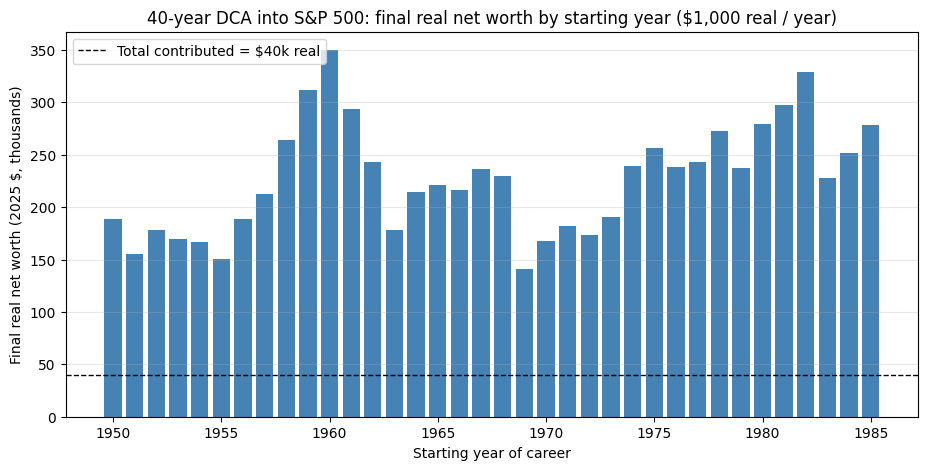

In [ ]:
dca.plot_cohorts(t40, n_years=40);

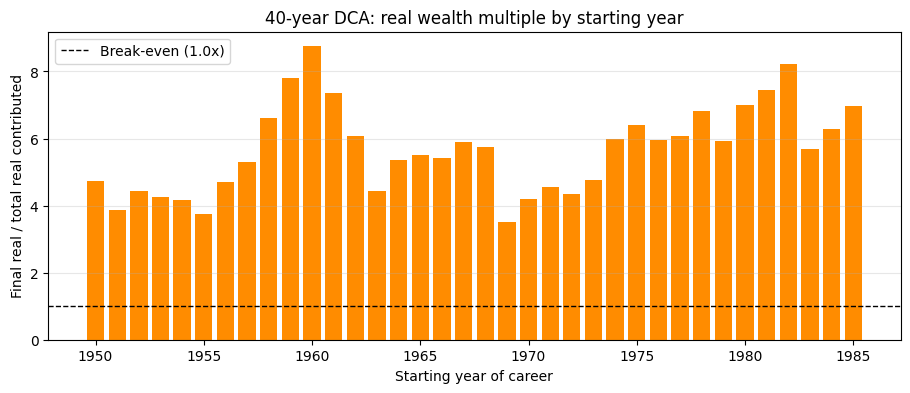

In [ ]:
dca.plot_multiple(t40, n_years=40);

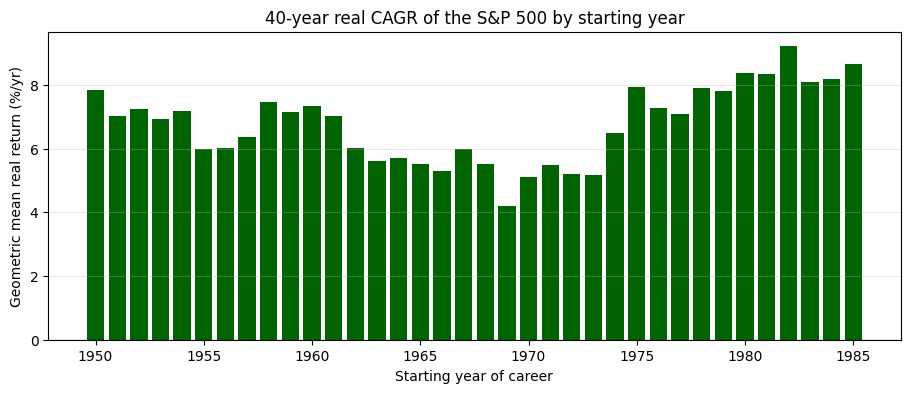

In [ ]:
dca.plot_cagr(t40, n_years=40);

### What stands out

- **Best cohort:** the worker who started in **1982** retires with the largest
  inflation-adjusted nest egg — they caught the 1982–2000 bull market entirely
  in the accumulation phase, with the biggest contributions invested earliest.
- **Worst cohort:** the worker who started in **1969** does the worst — they
  retired in 2008 right into the GFC and their career covered the 1970s
  stagflation. They still came out ahead, but only by about **3.5×** their
  real contributions (\$141k on \$40k contributed), vs. **8.2×** for the lucky
  cohort.
- **Range:** the best 40-year cohort accumulates roughly **2.3× more** real
  wealth than the worst, off the same real saving rate. Same discipline, same
  index, same plan — pure timing.
- **The middle is wide too.** Cohorts that retired into 2000 or 2008 (started
  in 1961 and 1969 respectively) gave back a chunk of their accumulated wealth
  in the last year of their career — a reminder that "average historical return"
  is not the same as the return *you actually get*.


## 10-year horizons: starting 1950 through 2015

A 10-year window is short enough that the *sequence* of returns dominates: there
are not enough years for compounding to wash out a bad decade. The dispersion
across cohorts gets much wider, and several cohorts end up with **less real wealth
than they contributed**.


In [ ]:
t10 = dca.cohort_table(returns, range(1950, 2016), n_years=10)
print(t10.to_string(index=False,
    formatters={
        'final_real_net_worth': '${:,.0f}'.format,
        'multiple_of_contributed': '{:.2f}x'.format,
        'real_cagr': '{:.2%}'.format,
    }))

 start_year  end_year final_real_net_worth multiple_of_contributed real_cagr
       1950      1959              $24,865                   2.49x    16.86%
       1951      1960              $20,900                   2.09x    14.31%
       1952      1961              $22,758                   2.28x    15.17%
       1953      1962              $17,685                   1.77x    12.16%
       1954      1963              $18,738                   1.87x    14.51%
       1955      1964              $18,288                   1.83x    11.26%
       1956      1965              $18,064                   1.81x     9.27%
       1957      1966              $14,477                   1.45x     7.31%
       1958      1967              $16,163                   1.62x    10.83%
       1959      1968              $15,204                   1.52x     7.67%
       1960      1969              $12,191                   1.22x     5.09%
       1961      1970              $11,328                   1.13x     5.00%

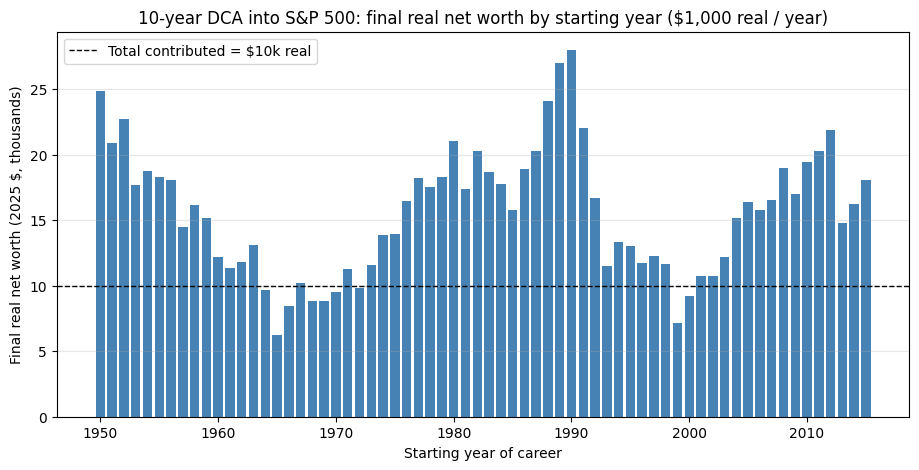

In [ ]:
dca.plot_cohorts(t10, n_years=10);

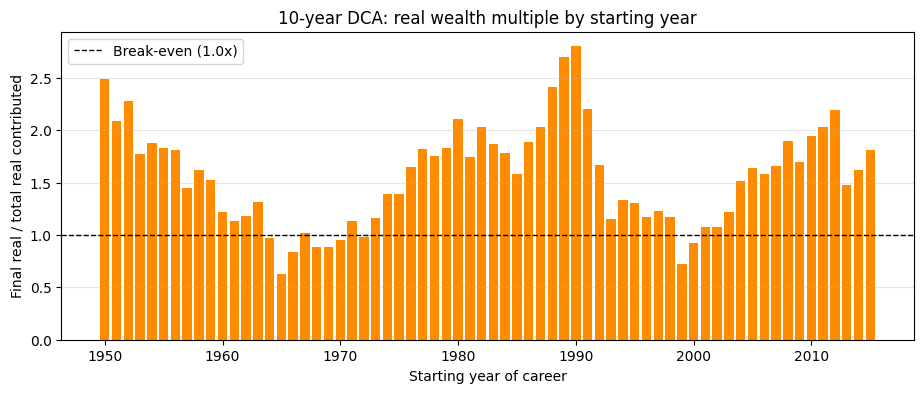

In [ ]:
dca.plot_multiple(t10, n_years=10);

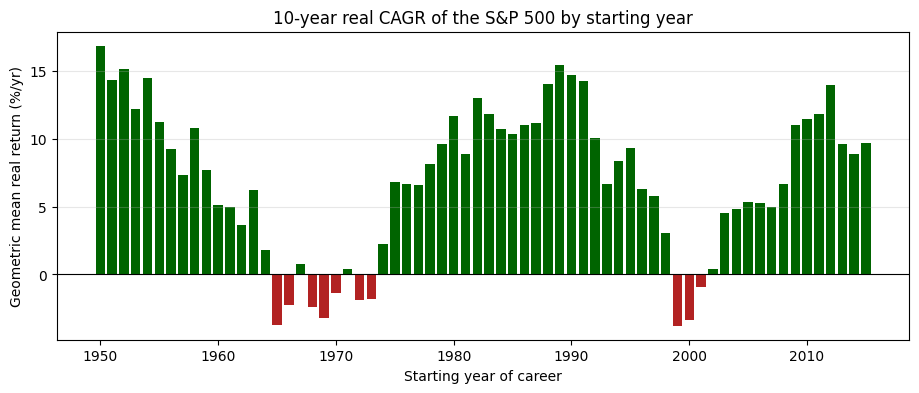

In [ ]:
dca.plot_cagr(t10, n_years=10);

### What stands out

- **Underwater cohorts.** Decades starting in **1964–1972** (stagflation) and
  in **1999–2000** (dot-com bust into GFC) finish *below* \$10,000 of real
  contributions — the only thing that saved them was that they were still
  working, not retiring. The 1965 cohort retired with **\$6,252** in real
  dollars after contributing \$10,000 — a 37% real loss over a decade.
- **Best 10-year window:** starting in **1988–1990** (catching the dot-com
  run-up) or **1950–1952** (the post-war bull) more than doubled the
  contributions in real terms over a single decade.
- **Real CAGR ranges from roughly –4%/yr to +17%/yr** depending on which decade
  you got. Compound that over a career and you get the dispersion we saw above.


## Takeaways

1. **Sequence-of-returns risk is real and large, even for buy-and-hold index investors.**
   The same disciplined \$1,000/year real saver retires with anywhere from
   roughly \$140k to \$330k in 2025 dollars depending purely on which year they
   happened to start their career. Holding the index is necessary; it is not
   sufficient to guarantee a particular outcome.
2. **40 years smooths a lot, but not everything.** The 40-year real CAGRs range
   from ~4%/yr (cohorts who started just before the 1970s stagflation) to
   ~9%/yr (cohorts who started just before the long 1982–2000 bull). Compounded
   over a career that 5pp gap is a factor-of-2+ difference in retirement wealth.
3. **10-year windows can lose money in real terms.** Several decade-long cohorts
   end up with *less* purchasing power than they contributed. This is why
   target-date funds and bond ladders exist for people who are 10 years from
   retirement — the equity premium is an asymptotic statement, not a guarantee
   over short horizons.
4. **The lesson is not "time the market" — it's "extend the horizon."**
   You cannot pick your starting year, but you can pick how long you stay
   invested. Going from 10 years to 40 years compresses the dispersion of
   outcomes dramatically (and shifts the whole distribution up).

## Sources

- [Aswath Damodaran — Historical Returns on Stocks, Bonds and Bills (NYU Stern)](https://pages.stern.nyu.edu/~adamodar/New_Home_Page/datafile/histretSP.html)
- [FRED — CPI for All Urban Consumers: All Items (CPIAUCNS)](https://fred.stlouisfed.org/series/CPIAUCNS)
- [Shiller, Robert J. — Online Data (Irrational Exuberance)](http://www.econ.yale.edu/~shiller/data.htm) (cross-check)


## What if the contribution is 10% of median household income?

The \$1,000-real-per-year saver is a useful unit because every cohort puts in
the same amount and we can read variation in outcomes as pure variation in
returns. But real median household income isn't constant — it grew from about
\$36,600 in 1950 to about \$88,500 in 2024 (real 2025 dollars, spliced
household / family series; see method note below). A worker saving a fixed
**fraction** of household income contributes more in real terms in later
career years and in later cohorts.

For this section each cohort contributes **10% of that year's real median
household income**. Two things change vs. the \$1,000-flat version:

1. *Within* a career, real contributions rise over time — so when real
   household income grew (most cohorts before 2000), the bigger contributions
   land in the later career years, where they compound for fewer years. That
   *dampens* the final wealth gain a bit relative to a flat real contribution
   of the same average size.
2. *Across* cohorts, later starters benefit from higher real income, so their
   total real contributions are larger.

**Source for median household income:** [FRED MEHOINUSA672N (real median household income, 2023 CPI-U-RS dollars)](https://fred.stlouisfed.org/series/MEHOINUSA672N) for 1984–2024, spliced via the 1984 HH/Family ratio (~0.85) onto [FRED MEFAINUSA672N (real median family income)](https://fred.stlouisfed.org/series/MEFAINUSA672N) for 1953–1983, held flat at 1953 for 1950–1952, then inflated to ~2025 dollars using the same CPI series as the rest of the analysis.


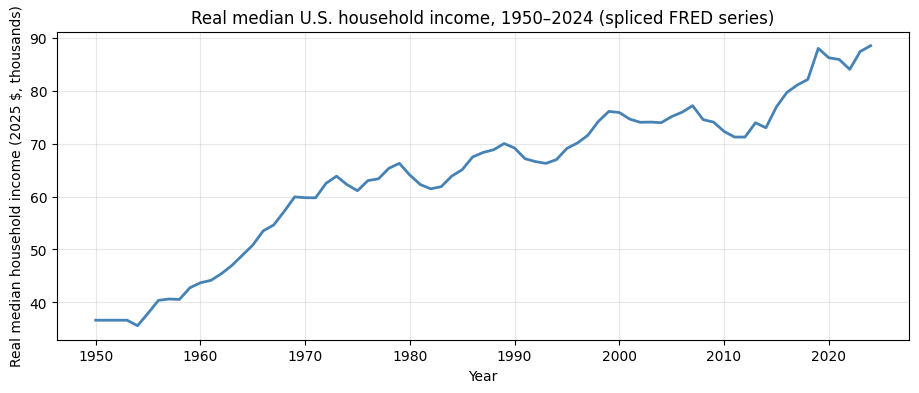

In [ ]:
income = dca.load_median_hh_income()
contributions = income * 0.10

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(income.index, income.values / 1000, color='steelblue', linewidth=2)
ax.set_xlabel('Year')
ax.set_ylabel('Real median household income (2025 $, thousands)')
ax.set_title('Real median U.S. household income, 1950–2024 (spliced FRED series)')
ax.grid(alpha=0.3);

### 40-year careers — 10% of median household income

In [ ]:
t40i = dca.cohort_table_variable(returns, contributions, range(1950, 1986), n_years=40)
print(t40i.to_string(index=False,
    formatters={
        'total_real_contributed': '${:,.0f}'.format,
        'final_real_net_worth': '${:,.0f}'.format,
        'multiple_of_contributed': '{:.2f}x'.format,
        'real_cagr': '{:.2%}'.format,
    }))

 start_year  end_year total_real_contributed final_real_net_worth multiple_of_contributed real_cagr
       1950      1989               $217,026             $877,345                   4.04x     7.85%
       1951      1990               $220,280             $739,155                   3.36x     7.04%
       1952      1991               $223,332             $872,218                   3.91x     7.25%
       1953      1992               $226,329             $855,181                   3.78x     6.94%
       1954      1993               $229,293             $864,925                   3.77x     7.18%
       1955      1994               $232,432             $804,013                   3.46x     5.99%
       1956      1995               $235,548           $1,032,883                   4.39x     6.03%
       1957      1996               $238,521           $1,184,871                   4.97x     6.37%
       1958      1997               $241,615           $1,497,138                   6.20x     7.46%


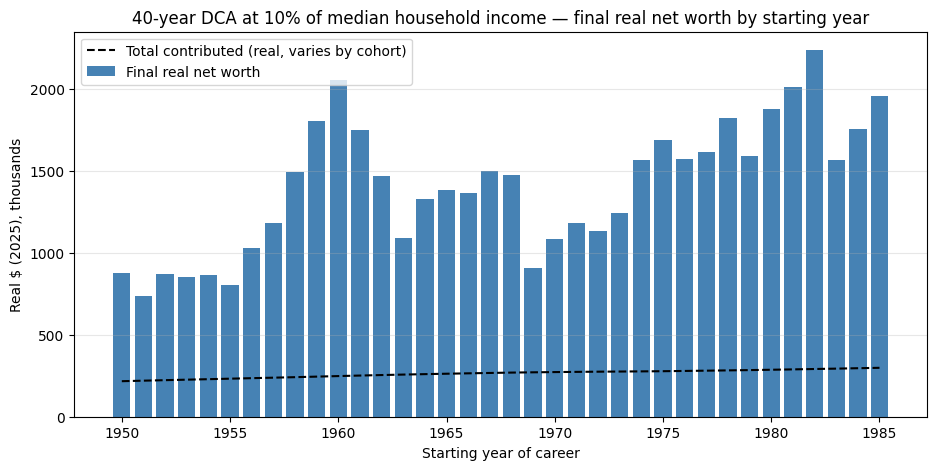

In [ ]:
dca.plot_cohorts_variable(t40i, n_years=40,
    title='40-year DCA at 10% of median household income — final real net worth by starting year');

### 10-year horizons — 10% of median household income

In [ ]:
t10i = dca.cohort_table_variable(returns, contributions, range(1950, 2016), n_years=10)
print(t10i.to_string(index=False,
    formatters={
        'total_real_contributed': '${:,.0f}'.format,
        'final_real_net_worth': '${:,.0f}'.format,
        'multiple_of_contributed': '{:.2f}x'.format,
        'real_cagr': '{:.2%}'.format,
    }))

 start_year  end_year total_real_contributed final_real_net_worth multiple_of_contributed real_cagr
       1950      1959                $38,445              $93,397                   2.43x    16.86%
       1951      1960                $39,152              $79,552                   2.03x    14.31%
       1952      1961                $39,905              $88,075                   2.21x    15.17%
       1953      1962                $40,783              $69,808                   1.71x    12.16%
       1954      1963                $41,817              $75,949                   1.82x    14.51%
       1955      1964                $43,147              $77,296                   1.79x    11.26%
       1956      1965                $44,434              $78,676                   1.77x     9.27%
       1957      1966                $45,747              $64,589                   1.41x     7.31%
       1958      1967                $47,146              $74,282                   1.58x    10.83%


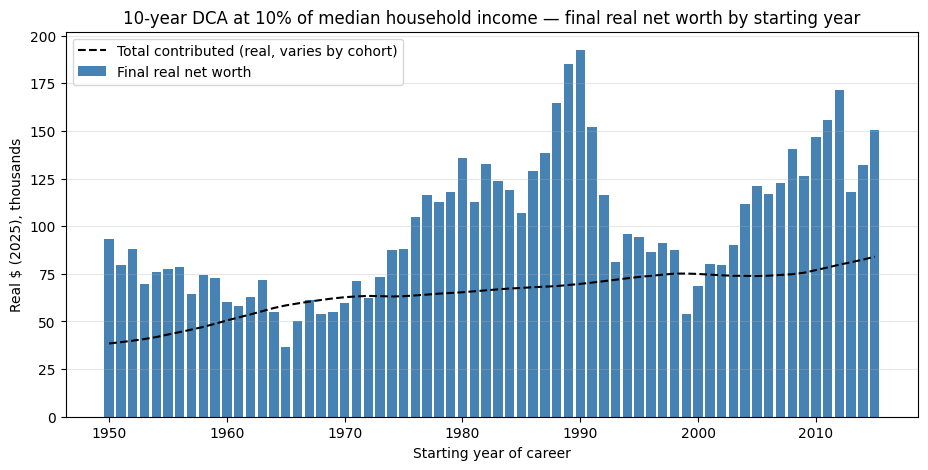

In [ ]:
dca.plot_cohorts_variable(t10i, n_years=10,
    title='10-year DCA at 10% of median household income — final real net worth by starting year');

### What changes vs. the flat-\$1,000 version

- **Absolute wealth scales up by ~7x.** A 10% savings rate on median household
  income averages roughly \$6,000–\$9,000/year real, vs. \$1,000 flat. The
  shape of the cohort curve is similar, but the y-axis is now in *millions*
  rather than hundreds of thousands.
- **Multiple of contributions compresses slightly.** Because the contribution
  *grew* in real terms within most cohorts' careers (real median household
  income roughly doubled from 1953 to 2024), the largest contributions
  arrived late and had fewer years to compound. So the same return path
  produces a smaller final-wealth multiple of contributed dollars than the
  flat-real version above.
- **Cohort ranking is essentially unchanged.** The relative dispersion across
  cohorts comes from the return sequence, which is identical to the flat
  version. Best and worst cohorts move by a year or two but the picture is
  the same: the 1982 starter still wins, the 1969 starter still loses.
